# Lab: XAI and Uncertainty for Time-Series Forecasting (Panama Load)

You are data scientists at a grid operator in Panama. Your task is short-term load forecasting, interpreting model behaviour (XAI), and estimating predictive uncertainty so operators can make safer operational decisions. This notebook walks you through EDA, feature engineering, training a model, SHAP explanations, temporal attribution with occlusion, bootstrap-based variability, and conformal prediction intervals.

Follow the TODO markers in code cells. The dataset is expected at `data/panama_load.csv` and should contain at least a timestamp column and a load column. Optional covariates (temperature, humidity, etc.) are welcome.

In [2]:
# Section 0 - Setup
# Imports, plotting style, and random seed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
import shap
import warnings
warnings.filterwarnings('ignore')

# Plot style and seed
sns.set_style('whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1 — Load data and basic EDA

Goal: understand the time series, inspect seasonality, and spot anomalies. Follow instructions and fill TODOs.

You can learn more about the dataset at: https://www.kaggle.com/datasets/saurabhshahane/electricity-load-forecasting

In [3]:
# 1) Load data into a DataFrame
path = '../data/panama_load.csv'
if not os.path.exists(path):
    print(f'WARNING: {path} not found. Please place the dataset at this path.')
df = pd.read_csv(path)
print(f'Data loaded with shape: {df.shape}')

Data loaded with shape: (48048, 17)


In [4]:
datetime_col = 'datetime' 
load_col = 'nat_demand'  
# Attempt to parse a datetime column robustly
if datetime_col not in df.columns:
    # try to guess a datetime-like column
    for c in df.columns:
        if 'date' in c.lower() or 'time' in c.lower():
            datetime_col = c
            break
print('Using datetime column:', datetime_col)
# Parse datetimes
try:
    df[datetime_col] = pd.to_datetime(df[datetime_col])
except Exception as e:
    print('Error parsing datetimes:', e)
# Set index and sort
df = df.set_index(datetime_col).sort_index()

print('Using load column:', load_col)
# Keep a clean dataframe with at least datetime index and load
data = df[[load_col]].copy()
data.columns = ['load']
data = data.sort_index()
data.head()

Using datetime column: datetime
Using load column: nat_demand


,load
datetime,
2015-01-03 01:00:00,970.3450
2015-01-03 02:00:00,912.1755
2015-01-03 03:00:00,900.2688
2015-01-03 04:00:00,889.9538
2015-01-03 05:00:00,893.6865


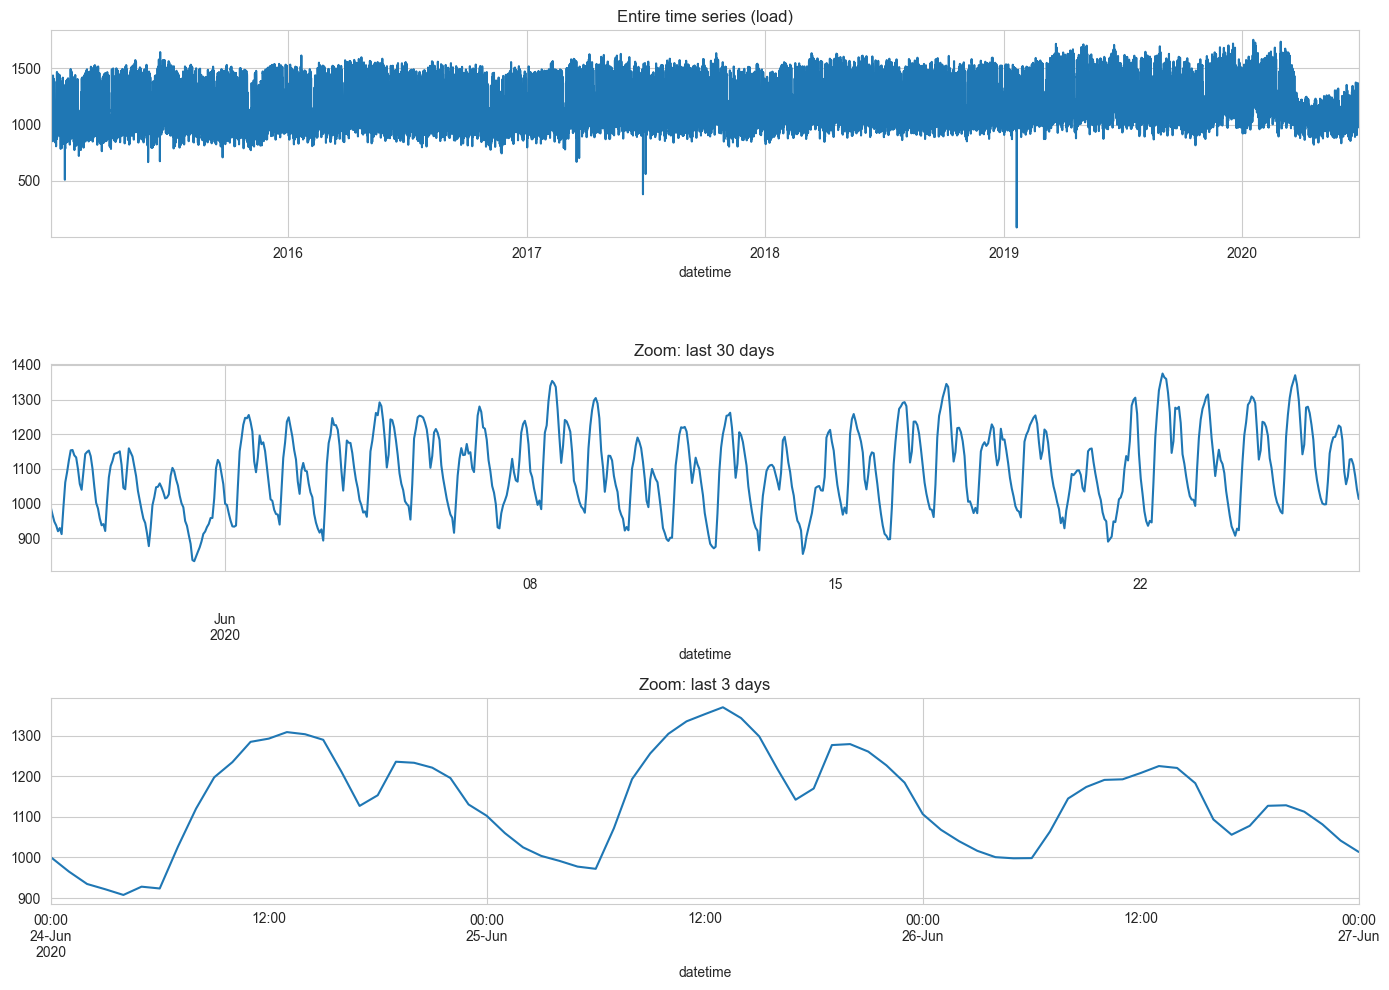

In [5]:
# 2) Basic plots: entire series, one month, a couple of days
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
# Entire series
data['load'].plot(ax=ax[0], title='Entire time series (load)')
# Zoom into one month (choose the last available month)
last = data.index.max()
month_start = (last - pd.Timedelta(days=30)).ceil('D')
data.loc[month_start:last, 'load'].plot(ax=ax[1], title='Zoom: last 30 days')
# Zoom into a couple of days
days_start = (last - pd.Timedelta(days=3)).ceil('D')
data.loc[days_start:last, 'load'].plot(ax=ax[2], title='Zoom: last 3 days')
plt.tight_layout()
plt.show()

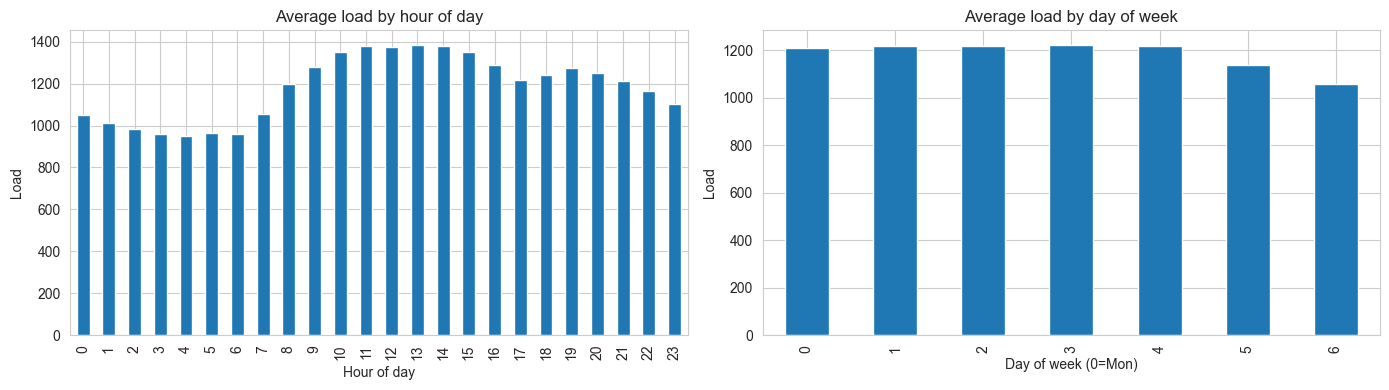

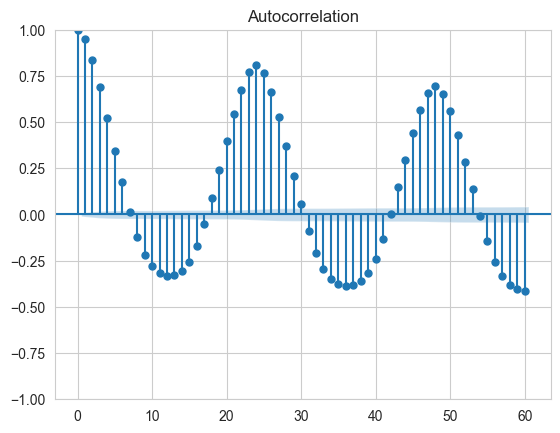

In [6]:
# 3) Average load by hour-of-day and day-of-week
df_feats = data.copy()
df_feats['hour'] = df_feats.index.hour
df_feats['dow'] = df_feats.index.dayofweek
hourly = df_feats.groupby('hour')['load'].mean()
dow = df_feats.groupby('dow')['load'].mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
hourly.plot(kind='bar', ax=ax1, title='Average load by hour of day')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Load')
dow.plot(kind='bar', ax=ax2, title='Average load by day of week')
ax2.set_xlabel('Day of week (0=Mon)')
ax2.set_ylabel('Load')
plt.tight_layout()
plot_acf(data['load'].dropna(), lags=60)
plt.show()


- TODO: Inspect the previous plots and comment on the patterns you can distinguish

>>> En las gráficas podemos distinguir varias cosas:
- Estacionalidad diaria: esto se puede ver en el gráfico de los 3 días aumentados especialmente y en la media por hora del día. Estos plots pintan un ciclo que se repite de manera regular cada 24 horas, con los mínimos en la madrugada (más o menos entre las 3 y las 6) y con los máximos al final de la mañana (entre las 11 y las 14).
- Estacionalidad semanal: esta estacional en los gráficos de los 30 días y anual se ve menos, pero en el histograma de la media por día de la semana se puede apreciar que la demanda es mayor de lunes a viernes y más pequeña los fines de semana (en especial el domingo)
- Autocorrelación temporal: en el último gráfico se puede ver que existen picos en los lags 24 y 48 lo que indica que hay ciclos diarios. Además, se puede ver que en los primeros lags la correlación tambien es muy alta, lo que tiene bastante sentido ya que los valores recientes influyen bastante en el valor actual.
- Tendencia general: en la primera gráfica se puede ver que no hay ni una tendencia creciente ni decreciente a largo plazo. Lo único que se puede ver son pequeñas fluctuaciones en momentos concretos que pueden deberse a eventos puntuales. Al final de la gráfica se puede ver como de repende hay un descenso en el consumo aproximadamente en febrero-marzo de 2020 que coincide con el momento de inicio de la pandemia del Covid-19

Con todas estas cosas se puede ver claramente que tenemos unos datos con una estructura temporal fuerte y repetitiva.

## Section 2 — Turn time series into supervised learning data

We convert the time series into a tabular supervised problem: predict 1-step-ahead load from lag features, rolling statistics and calendar features.
Fill TODOs in the helper function below.

In [7]:
def make_supervised(df, target_col='load', horizon=1, lags=None):
    """Create supervised features for a 1-step-ahead forecast."""
    if lags is None:
        lags = [1, 24, 48, 168]  # t-1, t-24 (daily), t-48, t-168 (weekly)
    X = pd.DataFrame(index=df.index)
    # Lag features
    for lag in lags:
        X[f'lag_{lag}'] = df[target_col].shift(lag)
    # Rolling features: 24-hour and 7-day rolling mean/std
    # X['rmean_24'] = df[target_col].rolling(window=24, min_periods=1).mean().shift(1)
    # X['rstd_24'] = df[target_col].rolling(window=24, min_periods=1).std().shift(1)
    # X['rmean_168'] = df[target_col].rolling(window=168, min_periods=1).mean().shift(1)
    X['rmean_24'] = df[target_col].shift(1).rolling(window=24, min_periods=1).mean()
    X['rstd_24'] = df[target_col].shift(1).rolling(window=24, min_periods=1).std()
    X['rmean_168'] = df[target_col].shift(1).rolling(window=168, min_periods=1).mean()
    
    # Calendar features
    X['hour'] = df.index.hour
    X['dow'] = df.index.dayofweek
    X['is_weekend'] = (X['dow'] >= 5).astype(int)
    X['month'] = df.index.month
    # Target (1-step ahead by default)
    y = df[target_col].shift(-horizon)
    # Align and drop NaNs caused by shifts
    X = X.loc[~y.isna()]
    y = y.loc[X.index]
    return X, y
# Build supervised data
X, y = make_supervised(data, target_col='load', horizon=1)
print('X shape:', X.shape, 'y shape:', y.shape)
# show a few rows
X.head()

X shape: (48047, 11) y shape: (48047,)


,lag_1,lag_24,lag_48,lag_168,rmean_24,rstd_24,rmean_168,hour,dow,is_weekend,month
datetime,,,,,,,,,,,
2015-01-03 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,1
2015-01-03 02:00:00,970.3450,NaN,NaN,NaN,970.345000,NaN,970.345000,2,5,1,1
2015-01-03 03:00:00,912.1755,NaN,NaN,NaN,941.260250,41.132048,941.260250,3,5,1,1
2015-01-03 04:00:00,900.2688,NaN,NaN,NaN,927.596433,37.496964,927.596433,4,5,1,1
2015-01-03 05:00:00,889.9538,NaN,NaN,NaN,918.185775,35.938700,918.185775,5,5,1,1


## Section 3 — Time-based train / calibration / test split

Random splits leak future information in time series. We'll split chronologically: TRAIN (first 60%), CALIBRATION (next 20%), TEST (last 20%). The calibration set will be used for conformal prediction intervals.


In [8]:
# Chronological split
n = len(X)
i_train = int(n * 0.6)
i_cal = int(n * 0.8)
X_train = X.iloc[:i_train]
y_train = y.iloc[:i_train]
X_cal = X.iloc[i_train:i_cal]
y_cal = y.iloc[i_train:i_cal]
X_test = X.iloc[i_cal:]
y_test = y.iloc[i_cal:]
print('TRAIN range:', X_train.index.min(), 'to', X_train.index.max(), 'size', len(X_train))
print('CAL range:', X_cal.index.min(), 'to', X_cal.index.max(), 'size', len(X_cal))
print('TEST range:', X_test.index.min(), 'to', X_test.index.max(), 'size', len(X_test))

TRAIN range: 2015-01-03 01:00:00 to 2018-04-18 04:00:00 size 28828
CAL range: 2018-04-18 05:00:00 to 2019-05-23 13:00:00 size 9609
TEST range: 2019-05-23 14:00:00 to 2020-06-26 23:00:00 size 9610


## Section 4 — Baseline model and ML model

We compare a naive baseline (previous value) to a trained tree-based regressor. Evaluate using MAE and RMSE.


Naive baseline MAE: 78.688, RMSE: 100.701
RandomForest MAE: 35.878, RMSE: 54.299


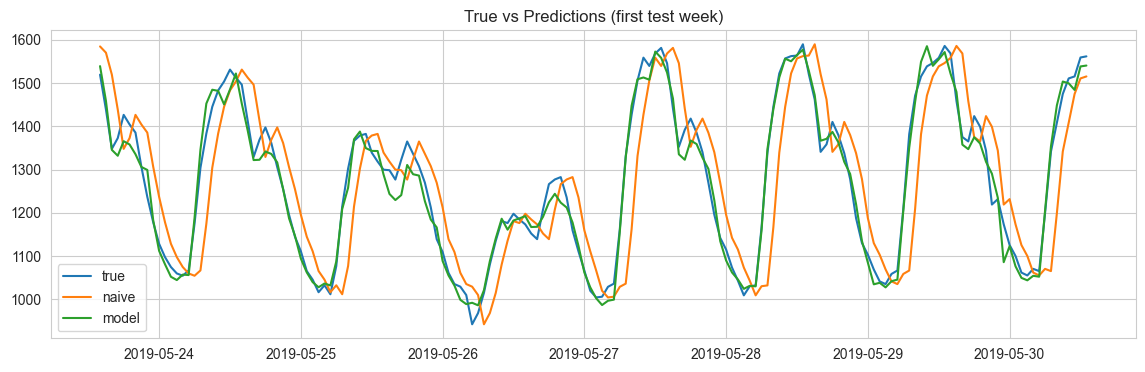

In [9]:
# Naive baseline: predict using lag_1 (t-1). Align carefully.
y_test_index = y_test.index
# Baseline predictions: because target is t, naive is previous observed load at t-1 which is lag_1 feature
yhat_naive = X_test['lag_1']
# Fit a RandomForest as example ML model (students can replace with XGBoost/LGBM)
model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
# TODO: fit the model on (X_train, y_train)
X_train.isna().sum()          # para ver por columna
X_train.isna().sum().sum()    # nº total de NaNs

# Eliminar filas con NaNs en TRAIN
mask_train = ~X_train.isna().any(axis=1)
X_train_clean = X_train.loc[mask_train]
y_train_clean = y_train.loc[mask_train]

# Eliminar filas con NaNs en TEST
mask_test = ~X_test.isna().any(axis=1)
X_test_clean = X_test.loc[mask_test]
y_test_clean = y_test.loc[mask_test]

X_train = X_train_clean.copy()
y_train = y_train_clean.copy()
X_test = X_test_clean.copy()
y_test = y_test_clean.copy()

model.fit(X_train, y_train)
# Predict on test
yhat = pd.Series(model.predict(X_test), index=X_test.index)
# Evaluation
def evaluate(y_true, y_pred, label='model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    print(f'{label} MAE: {mae:.3f}, RMSE: {rmse:.3f}')

evaluate(y_test, yhat_naive, label='Naive baseline')
evaluate(y_test, yhat, label='RandomForest')
# Plot a selected TEST week: choose first week of test set
try:
    plot_start = X_test.index[0]
    plot_end = plot_start + pd.Timedelta(days=7)
    idx = (y_test.index >= plot_start) & (y_test.index < plot_end)
    plt.figure(figsize=(14, 4))
    plt.plot(y_test.loc[idx].index, y_test.loc[idx].values, label='true')
    plt.plot(yhat_naive.loc[idx].index, yhat_naive.loc[idx].values, label='naive')
    plt.plot(yhat.loc[idx].index, yhat.loc[idx].values, label='model')
    plt.legend()
    plt.title('True vs Predictions (first test week)')
    plt.show()
except Exception as e:
    print('Could not plot test week:', e)

## Section 5 — Global and local XAI with SHAP

We use SHAP to explain feature importance globally and locally. For tree models, TreeExplainer is efficient. For other models, KernelExplainer may be used but is slower.


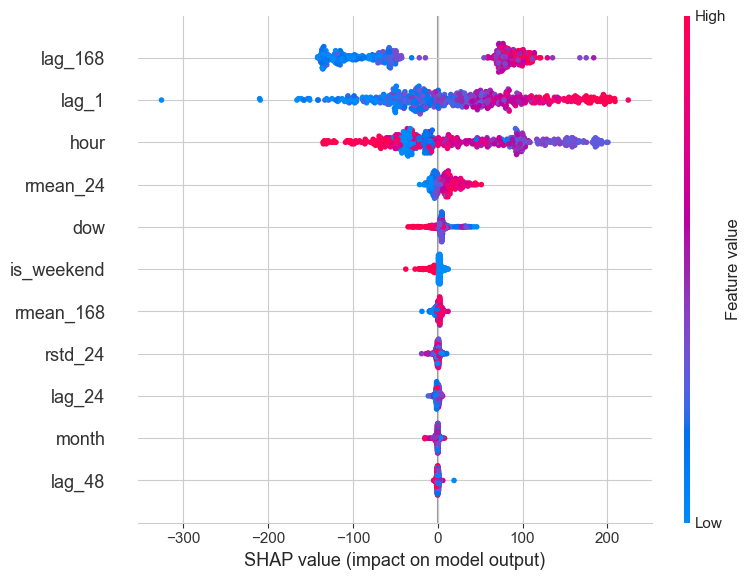

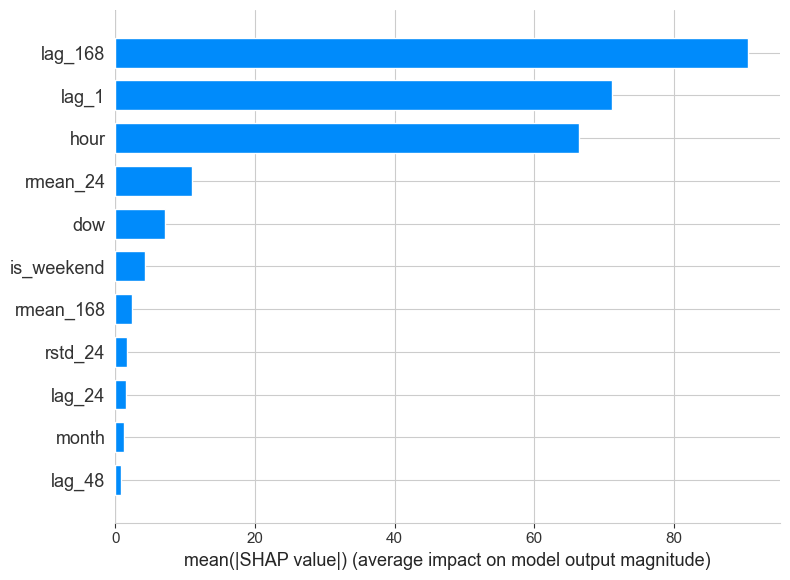

Index with highest load in test: 2020-01-17 13:00:00
Could not produce local SHAP waterfall: The waterfall plot requires an `Explanation` object as the `shap_values` argument.


In [10]:
# Select a subset of X_test for SHAP analysis (to keep compute small)
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_SEED)
# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_shap, show=True)
# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=True)
# Local explanation for a single interesting point (e.g., highest true load in test)
idx_max = y_test.idxmax()
print('Index with highest load in test:', idx_max)
x_local = X_test.loc[[idx_max]]
try:
    sv_local = explainer.shap_values(x_local)
    shap.plots.waterfall(sv_local[0] if isinstance(sv_local, list) else sv_local, max_display=12)
except Exception as e:
    print('Could not produce local SHAP waterfall:', e)

In [11]:
# Features relevantes según SHAP
important_features = ['lag_168', 'lag_1', 'hour', 'rmean_24', 'dow', 'is_weekend']

# Seleccionar solo esas columnas
X_train_simple = X_train[important_features].copy()
X_test_simple = X_test[important_features].copy()

print("Dimensiones antes:", X_train.shape)
print("Dimensiones después:", X_train_simple.shape)

Dimensiones antes: (28660, 11)
Dimensiones después: (28660, 6)


In [12]:
model_simple = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model_simple.fit(X_train_simple, y_train)

# Predicciones
yhat_simple = pd.Series(
    model_simple.predict(X_test_simple),
    index=y_test.index
)

# Evaluación
print("=== Modelo Simple ===")
evaluate(y_test, yhat_simple, label="RandomForest Simple")

=== Modelo Simple ===
RandomForest Simple MAE: 35.754, RMSE: 54.077


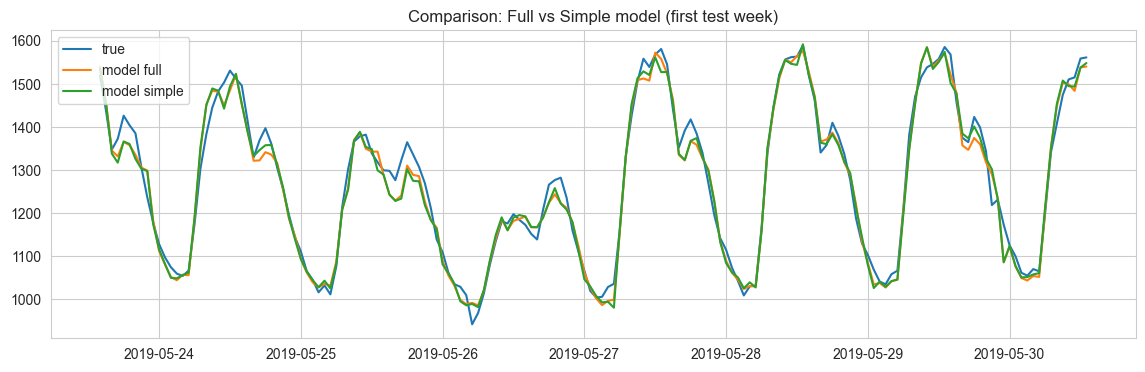

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.loc[idx].index, y_test.loc[idx].values, label='true')
plt.plot(yhat.loc[idx].index, yhat.loc[idx].values, label='model full')
plt.plot(yhat_simple.loc[idx].index, yhat_simple.loc[idx].values, label='model simple')
plt.legend()
plt.title('Comparison: Full vs Simple model (first test week)')
plt.show()

- TODO: Interpret SHAP results, are there any innecessary inputs? Try to simplify the model and check performance variations. Does SHAP results match domain intuition?

>>> Los resultados observados en SHAP nos permiten entender que variables son relevantes para el modelo y para las predicciones, y cuáles no. Observando los gráficos, destacaría 3 niveles de importancia en las distintas carancterísticas:

>>> - Muy influyentes: se puede ver como las caracteristicas lag_168, lag_1 y hour influyen mucho en l aprediccion lo que tiene sentido ya que existe un ciclo diario y semanal muy marcado. Gracias a estas tres caracteristicas se capta bien la repetitividad de los datos, influidos por el corto plazo (lag_1) ya que no todas las semanas son exactamente iguales ni todos los días. 
>>> - Influyentes: las caracterísiticas mean_24, dow y is_weekend aportan información que puede ayudar a ajustar mejor los picos / valles y las tendencias recientes. Es decir, mean_24 puede ayudar a ver si en el último día ha tendido a bajar o subir para ajustar mejor el nuevo día, y dow y is_weekend nos ayudan a saber si es fin de semana o no y así capturar mejor esa bajada de la que hablabamos en el analisis de la seccion 1. 
>>> - Poco influyentes: para el resto de características, el valor de SHAP es prácticamente nulo, lo que quiere decir que el modelo apenas utiliza estas variables para predecir. Esto puede ser porque o bien la información se incluye ya en otras características (como lag_24 y lag_48 que pueden describir las varaiciones diarias y semanales un poco peor que con hour y lag_168) o bien porque esa información no es relevante en si misma (rstd_24 no aporta casi nada porque la  variabilidad diaria es bastante estable)

>>> Para intentar simplificar el modelo, he eliminado las características poco influyentes para saber si realmente no influyen ni varian el rendimiento del modelo. Para realizar el experimento he utilizado el RandomForest que se utiliza previamente y que es bastante mejor que el naive, y lo he entrenado solo con las caracterísiticas muy influyentes e influyentes. En el resultado se puede ver que tanto el MAE como el RMSE son prácticamente iguales, incluso con una mejoría casi inapreciable. En el gráfico se muestra como con el modelo simple hay algún pico y valle que se ajusta un poquito mejor, pero que practicamente el resultado es el mismo. 

>>> Comprobando si todo este analisis de SHAP tiene sentido con la intuicion y el analisis hecho en la primera seccion, se puede ver que efectivamente todo encaja de manera razonable ya que muestra la correlacion a corto plazo y por eso lag_1 es importante, y se describe de manera clara la dependencia con el horario y el comportamiento semanal. Además, las caracterisitcas month y rstd_24 que shap muestra como poco influyentes, estarían describiendo la tendencia general en el año que en la seccion 1 hemos visto que no tenía, y la variabilidad que hemos visto que era muy estable. Por lo que todo tiene sentido

## Section 6 — Bootstrap ensemble for predictive variability

Train B bootstrap models (resampling training data with replacement) to approximate variability due to training data sampling. Use their distribution to produce prediction intervals.


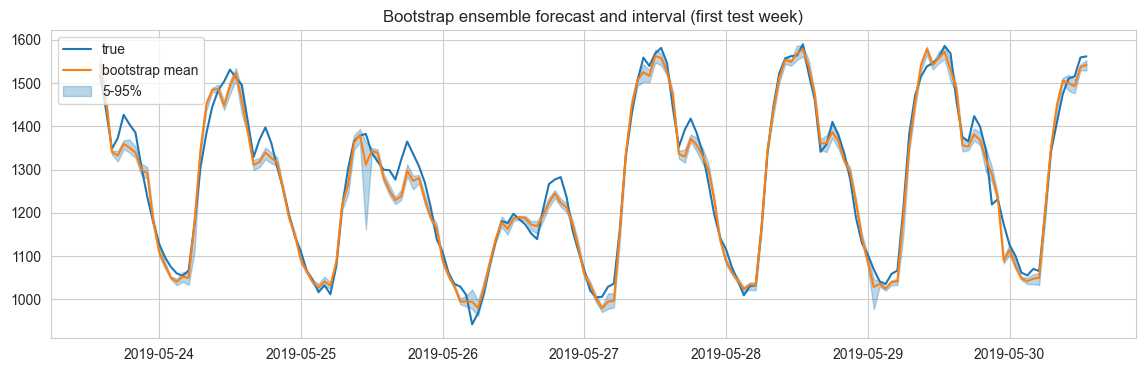

In [14]:
from copy import deepcopy
def bootstrap_models(X_train, y_train, base_model, B=10):
    models = []
    n = len(X_train)
    for b in range(B):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        Xb = X_train.iloc[idx]
        yb = y_train.iloc[idx]
        m = deepcopy(base_model)
        m.fit(Xb, yb)
        models.append(m)
    return models
# Train B bootstrap models (may take time)
B = 10
base = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)

# TODO: If running time is a concern reduce B or model complexity
models_b = bootstrap_models(X_train, y_train, base, B=B)
# Compute bootstrap predictions for X_test (may be memory heavy; sample a week for plotting)
def bootstrap_predict(models, X):
    preds = np.vstack([m.predict(X) for m in models])  # shape (B, n)
    return preds
preds_b = bootstrap_predict(models_b, X_test)
# Mean and 5th-95th percentile interval
y_mean = preds_b.mean(axis=0)
y_p05 = np.percentile(preds_b, 5, axis=0)
y_p95 = np.percentile(preds_b, 95, axis=0)
# Plot a test week with bootstrap interval
try:
    plot_start = X_test.index[0]
    plot_end = plot_start + pd.Timedelta(days=7)
    mask = (X_test.index >= plot_start) & (X_test.index < plot_end)
    plt.figure(figsize=(14, 4))
    plt.plot(y_test.loc[mask].index, y_test.loc[mask].values, label='true')
    plt.plot(X_test.loc[mask].index, y_mean[mask], label='bootstrap mean')
    plt.fill_between(X_test.loc[mask].index, y_p05[mask], y_p95[mask], color='C0', alpha=0.3, label='5-95%')
    plt.legend()
    plt.title('Bootstrap ensemble forecast and interval (first test week)')
    plt.show()
except Exception as e:
    print('Could not plot bootstrap week:', e)

## Section 7 — Conformal prediction intervals (inductive residual-based)

Inductive conformal uses residuals on a held-out calibration set to form a distribution of absolute errors; the quantile gives a symmetric interval around point predictions with finite-sample marginal coverage guarantees (under exchangeability).

Conformal q (alpha=0.1): 45.42794799999979
Coverage on TEST (alpha=0.1): 0.744, avg width: 90.856
   alpha          q  coverage   avg_width
0   0.05  61.731835  0.842872  123.463670
1   0.10  45.427948  0.744121   90.855896
2   0.20  31.857424  0.614568   63.714848


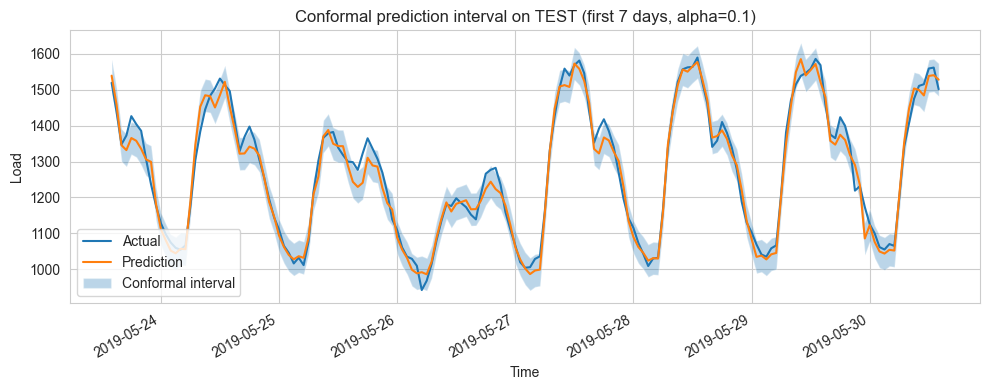

In [17]:
# --- Conformal quantile from calibration residuals ---

# Train a fresh model on TRAIN if desired. We'll reuse `model` already trained, but you can retrain here.
# model.fit(X_train, y_train)

# Predict on calibration set and compute residuals
yhat_cal = pd.Series(model.predict(X_cal), index=X_cal.index)
residuals = (y_cal - yhat_cal).abs()

def conformal_q(residuals, alpha=0.1):
    """
    Compute conformal quantile with finite-sample correction:
    quantile at ceil((n+1)*(1-alpha))/n.
    """
    n = len(residuals)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    q = np.sort(residuals)[k]
    return q

alpha = 0.1
q_alpha = conformal_q(residuals.values, alpha=alpha)
print(f'Conformal q (alpha={alpha}):', q_alpha)

# --- Build intervals on TEST ---

yhat_test = pd.Series(model.predict(X_test), index=X_test.index)
lower = yhat_test - q_alpha
upper = yhat_test + q_alpha

# Evaluate empirical coverage and average width
inside = ((y_test >= lower) & (y_test <= upper)).mean()
avg_width = (upper - lower).mean()
print(f'Coverage on TEST (alpha={alpha}): {inside:.3f}, avg width: {avg_width:.3f}')

# Optionally loop over several alphas
alphas = [0.05, 0.1, 0.2]
rows = []
for a in alphas:
    q = conformal_q(residuals.values, alpha=a)
    yhat_test_a = pd.Series(model.predict(X_test), index=X_test.index)
    l = yhat_test_a - q
    u = yhat_test_a + q
    cov = ((y_test >= l) & (y_test <= u)).mean()
    rows.append({'alpha': a, 'q': q, 'coverage': cov, 'avg_width': (u - l).mean()})

conformal_summary = pd.DataFrame(rows)
print(conformal_summary)

# --- Plot conformal predictions along the time series (first 7 days of TEST) ---

import matplotlib.pyplot as plt

# Define plot window: first 7 days of the test period
plot_start = X_test.index[0]
plot_end = plot_start + pd.Timedelta(days=7)

mask = (y_test.index >= plot_start) & (y_test.index <= plot_end)

y_test_plot = y_test[mask]
yhat_plot = yhat_test[mask]
lower_plot = lower[mask]
upper_plot = upper[mask]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(y_test_plot.index, y_test_plot, label='Actual')
ax.plot(yhat_plot.index, yhat_plot, label='Prediction')
ax.fill_between(yhat_plot.index, lower_plot, upper_plot, alpha=0.3, label='Conformal interval')

ax.set_title(f'Conformal prediction interval on TEST (first 7 days, alpha={alpha})')
ax.set_xlabel('Time')
ax.set_ylabel('Load')
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


- TODO: Comment on the results, which you find more useful: bootstrap or conformal? Which would you use in case I ask you about uncertainty in forecasting models?

>>> En la primera gráfica se puede ver como con bootstrap los intervalos son muy estrechos y casi se ajustan perfectamente a la predicción del modelo, salvo en momentos puntuales que los errores son muy notables con picos grandes. Esto muestra que es muy estable prediciendo casi lo mismo con modelos entrenados con muestras de los datos, es decir, que la varianza entre los modelos es muy baja. 

>>> En los segundos resultados se puede ver que con alpha=0.1, la cobertura es de un 74.4% sin llegar a ese 90% teórico al que debería llegar. Eso puede ser porque estamos trabajando con serie temporal y no con i.i.d. Se puede ver que salvo en los picos/valles, el intervalo sigue casi a la perfección las lineas de manera muy estrecha. En los picos y los valles el intervalo se enchancha pero sigue siempre mejor las lineas y no tiene esos errores tan notables con picos donde no tocan. 

>>> En función del objetivo podría encontrar más útil una o la otra. En el caso de querer evaluar la estabilidad del modelo para ver si este es sensible a cambios en los datos o si la prediccion es frágil, me parece mucho más útil bootstrap. Si lo que quiero es cuantificar la incertidumbre de predicción en forecasting (que es por lo que se nos está preguntando) sería más útil conformal ya que produce intervalos basados en errores reales. 

## Section 9 — Using intervals for anomaly flagging

Flag times where true load lies outside conformal intervals — potentially anomalous events requiring operator attention.


Number of anomalies in TEST: 2459


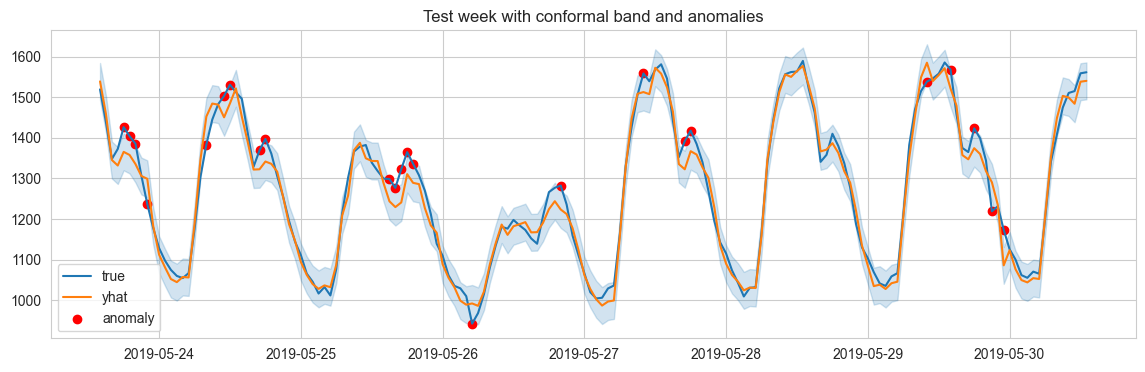

,y_true,yhat,lower,upper,anomaly
datetime,,,,,
2019-05-23 18:00:00,1426.328300,1365.446449,1320.018501,1410.874397,True
2019-05-23 19:00:00,1404.167525,1357.846409,1312.418461,1403.274357,True
2019-05-23 20:00:00,1385.319525,1335.390236,1289.962288,1380.818184,True
2019-05-23 22:00:00,1236.931400,1299.112335,1253.684387,1344.540283,True
2019-05-24 08:00:00,1383.298800,1452.513456,1407.085508,1497.941404,True
2019-05-24 11:00:00,1503.377200,1450.515194,1405.087246,1495.943142,True
2019-05-24 12:00:00,1530.904600,1484.892442,1439.464494,1530.320390,True
2019-05-24 17:00:00,1369.042600,1322.544027,1277.116079,1367.971975,True
2019-05-24 18:00:00,1397.329200,1341.674660,1296.246712,1387.102608,True


In [18]:
# Using alpha chosen earlier
yhat_test = pd.Series(model.predict(X_test), index=X_test.index)
lower = yhat_test - q_alpha
upper = yhat_test + q_alpha
anomaly = ~( (y_test >= lower) & (y_test <= upper) )
anomalies = pd.DataFrame({'y_true': y_test, 'yhat': yhat_test, 'lower': lower, 'upper': upper, 'anomaly': anomaly})
print('Number of anomalies in TEST:', anomalies['anomaly'].sum())
# Plot a test week with anomalies marked
try:
    mask = (X_test.index >= X_test.index[0]) & (X_test.index < X_test.index[0] + pd.Timedelta(days=7))
    plt.figure(figsize=(14, 4))
    plt.plot(anomalies.loc[mask].index, anomalies.loc[mask, 'y_true'], label='true')
    plt.plot(anomalies.loc[mask].index, anomalies.loc[mask, 'yhat'], label='yhat')
    plt.fill_between(anomalies.loc[mask].index, anomalies.loc[mask, 'lower'], anomalies.loc[mask, 'upper'], color='C0', alpha=0.2)
    # mark anomalies
    an_idx = anomalies.loc[mask & anomalies['anomaly']].index
    plt.scatter(an_idx, anomalies.loc[an_idx, 'y_true'], color='red', label='anomaly')
    plt.legend()
    plt.title('Test week with conformal band and anomalies')
    plt.show()
except Exception as e:
    print('Could not plot anomalies:', e)
# Print a small table of anomalies (timestamp, y_true, yhat, lower, upper)
anomalies[anomalies['anomaly']].head(20)

- TODO: Are the anomalies true grid events or model errors? Justify your answer

>>> Los puntos que se detectan como anomalías son errores del modelo y no como eventos de la red, por varios motivos: 

>>>- Se detecta un número muy alto de anomalías y en una red eléctrica real no se tienen tantos incidentes o fallos.
>>> - Los puntos marcados siguen la forma normal de la curva. Los puntos marcados se observan en los picos, los vales o donde hay cambios rápidos, que son las zonas donde el modelo tiende a cometer errores, pero la red sigue un comportamiento normal.
>>> - La cobertura del intervalo conformal es baja. Debido a que estamos trabajadno con una serie temporal y no con i.i.d, el intervalo queda muy estrecho (0.74 en vez de el 0.9 teórico) y esto hace que valores que son normales queden fuera del intervalo y se reconozcan como anomalos. De hecho, si nos fijamos los puntos marcados están tan pegados al intervalo que parece que están incluso dentro.

## Section 10 — Visualizing

How would you present these results to non-technical stakeholders at a grid operator? Include visuals and short bullet recommendations. Add as many code and markdown cells as you find necessary.

>>> Este modelo no solo predice la demanda eléctrica hora a hora, sino que también proporciona un rango donde se espera que se encuentra la demanda real. Este intervalo permite anticipar posibles desviaciones antes de que afecten a la operación. Esta predicción y los intervalos se pueden ver en la siguiente gráfica donde 

- la curva real se muestra con la linea azul
- la prediccion del modelo se muestra con la linea naranja
- el intervalo esperado se muestra en la zona azul clara. 

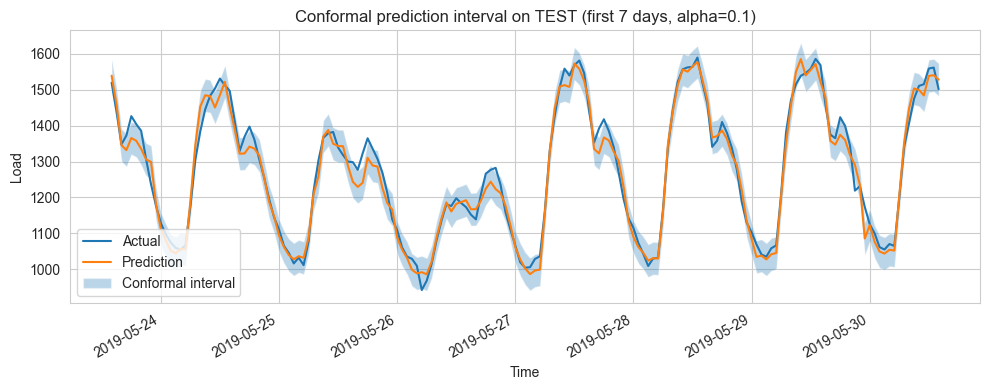

>>> Con esta imagen se puede identificar rápidamente periodos donde podría ser necesario revisar la generación de electricidad

>>> Además, los siguientes resultados muestran que hay 3 indicadores que son los más relevantes para la predicción por lo que deberían ser los datos más cuidados. En la gráfica a continuación se puede ver la importancia de las diferentes características que se han tenido en cuenta:

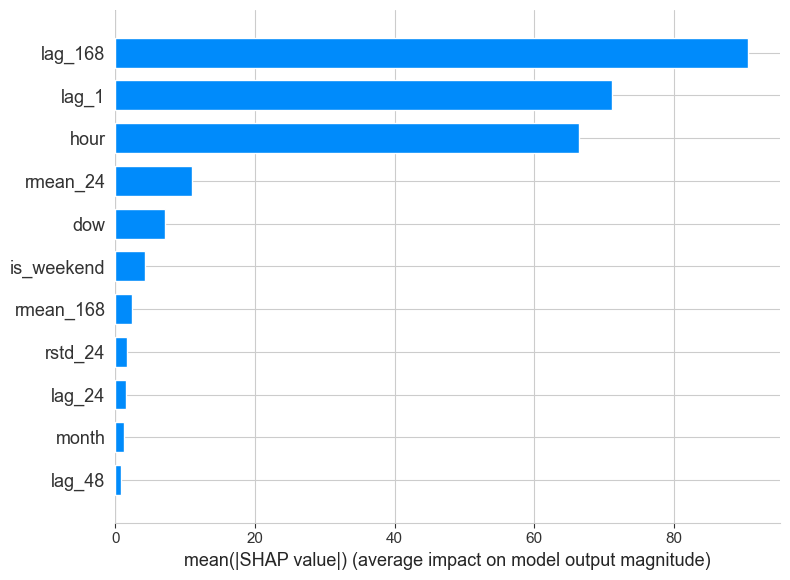

>>> Para ver si todo esto tiene sentido, es necesario que se comparen los resultados del modelo con los patrones reales que se observan en los datos históricos. En los siguientes gráficos, se muestra como la red presenta una estructura muy repetitiva con:
- picos de demanda a media mañana y primera hora de la tarde
- valores más bajos de madrugada
- ligera caída de demanda durante el fin de semana
>>> Como hemos mencionado en las caracterísiticas importantes, son estas las que describen precisamente estas regularidades, lo que quiere decir que nuestro modelo funciona correctamente.


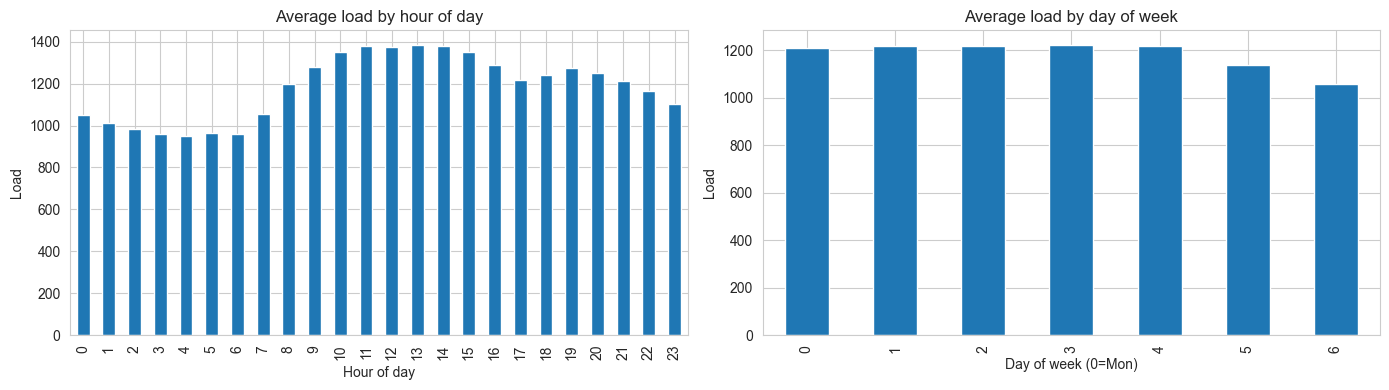
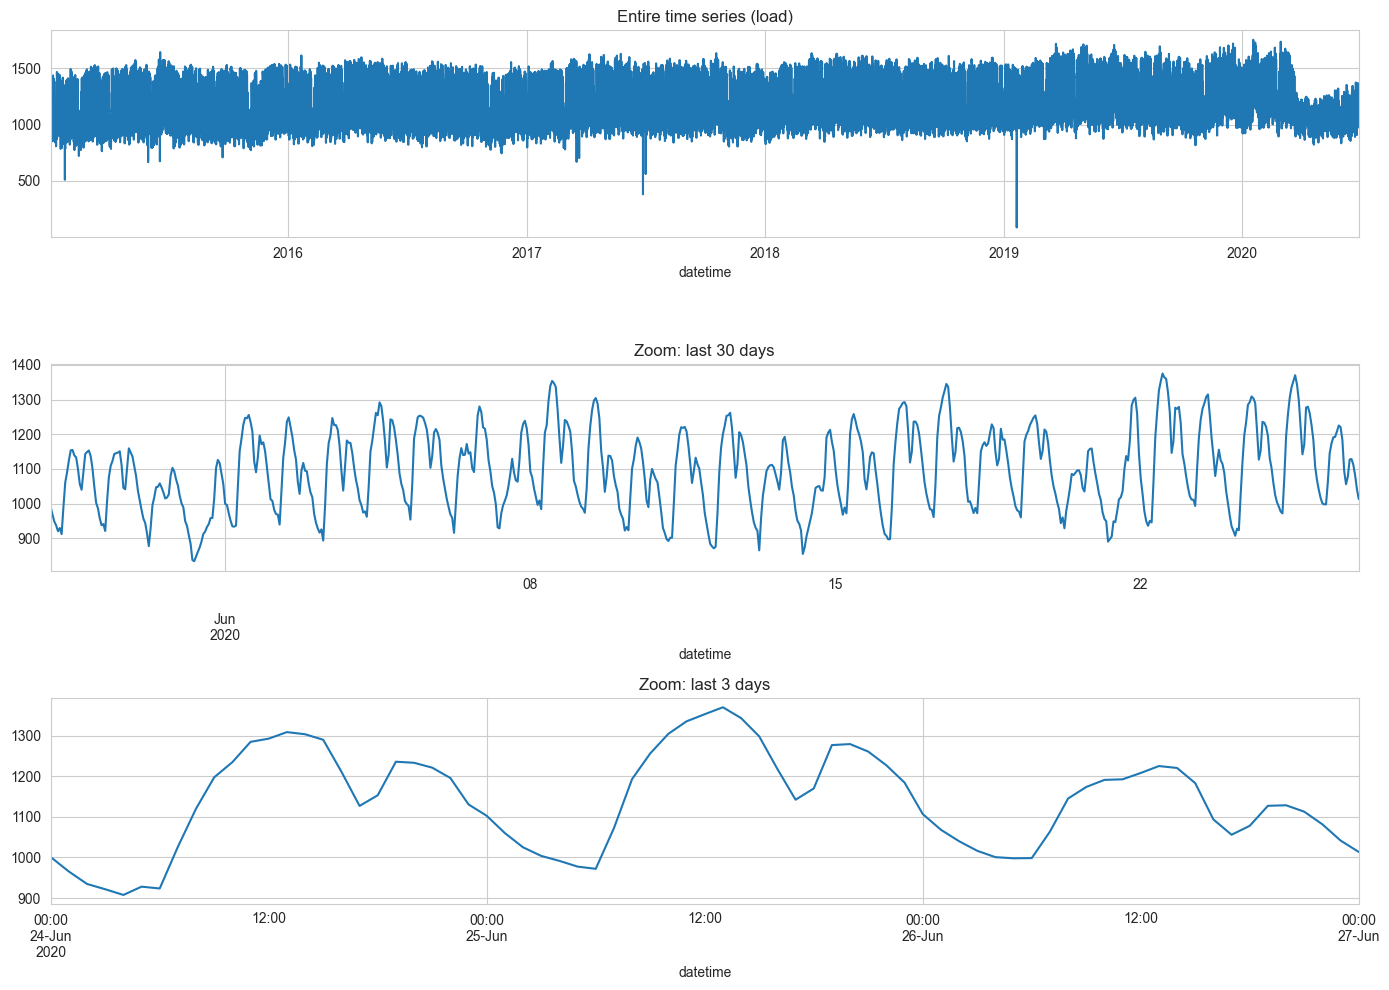

>>> Por último, cabe resaltar que nuestro modelo puede utilizarse también como una herramienta de apoyo para detectar comportamientos inusuales en la demanda. Comparando lo que predice el modelo con lo que realmente ocurre, podemos señalar momentos donde la demanda se desvía más de lo habitual.

>>> Con todo esto, el análisis puede apoyar en tres puntos: 
- Planificación operativa: ayuda a anticipar el nivel de la demanda y a preparar la generación necesaria
- Monitorización en tiempo real: facilita detectar rápidamente desviaciones importantes respecto a la demanda esperada
- Comprensión del comportamiento del sistema: ofrece indicadores intuitivos de que patrones condicionan la demanda
